# ***Imoporting Libraries***

In [185]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# ***Exploratory Data Analysis (EDA)***

In [186]:
df = pd.read_csv("/content/winequality-red.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [187]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [188]:
df.shape

(1599, 12)

In [189]:
df.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


In [190]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [192]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [193]:
df.duplicated().sum()

np.int64(240)

In [194]:
df.drop_duplicates(inplace=True)

In [195]:
df.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [196]:
df.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.255124,0.667437,0.111025,0.085886,-0.140580,-0.103777,0.670195,-0.686685,0.190269,-0.061596,0.119024
volatile acidity,-0.255124,1.000000,-0.551248,-0.002449,0.055154,-0.020945,0.071701,0.023943,0.247111,-0.256948,-0.197812,-0.395214
citric acid,0.667437,-0.551248,1.000000,0.143892,0.210195,-0.048004,0.047358,0.357962,-0.550310,0.326062,0.105108,0.228057
residual sugar,0.111025,-0.002449,0.143892,1.000000,0.026656,0.160527,0.201038,0.324522,-0.083143,-0.011837,0.063281,0.013640
chlorides,0.085886,0.055154,0.210195,0.026656,1.000000,0.000749,0.045773,0.193592,-0.270893,0.394557,-0.223824,-0.130988
free sulfur dioxide,-0.140580,-0.020945,-0.048004,0.160527,0.000749,1.000000,0.667246,-0.018071,0.056631,0.054126,-0.080125,-0.050463
total sulfur dioxide,-0.103777,0.071701,0.047358,0.201038,0.045773,0.667246,1.000000,0.078141,-0.079257,0.035291,-0.217829,-0.177855
density,0.670195,0.023943,0.357962,0.324522,0.193592,-0.018071,0.078141,1.000000,-0.355617,0.146036,-0.504995,-0.184252
pH,-0.686685,0.247111,-0.550310,-0.083143,-0.270893,0.056631,-0.079257,-0.355617,1.000000,-0.214134,0.213418,-0.055245
sulphates,0.190269,-0.256948,0.326062,-0.011837,0.394557,0.054126,0.035291,0.146036,-0.214134,1.000000,0.091621,0.248835


In [197]:
df.cov()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,3.017134,-0.081110,0.226692,0.260794,0.007366,-2.551078,-6.022271,0.002176,-0.184922,0.056405,-0.115772,0.170269
volatile acidity,-0.081110,0.033500,-0.019729,-0.000606,0.000498,-0.040050,0.438444,0.000008,0.007012,-0.008026,-0.039177,-0.059575
citric acid,0.226692,-0.019729,0.038235,0.038049,0.002029,-0.098065,0.309372,0.000131,-0.016683,0.010881,0.022239,0.036726
residual sugar,0.260794,-0.000606,0.038049,1.828752,0.001780,2.267926,9.082794,0.000820,-0.017432,-0.002732,0.092599,0.015192
chlorides,0.007366,0.000498,0.002029,0.001780,0.002438,0.000386,0.075509,0.000018,-0.002074,0.003325,-0.011959,-0.005327
free sulfur dioxide,-2.551078,-0.040050,-0.098065,2.267926,0.000386,109.145456,232.890476,-0.000353,0.091726,0.096508,-0.905779,-0.434189
total sulfur dioxide,-6.022271,0.438444,0.309372,9.082794,0.075509,232.890476,1116.157653,0.004879,-0.410519,0.201221,-7.874662,-4.893668
density,0.002176,0.000008,0.000131,0.000820,0.000018,-0.000353,0.004879,0.000003,-0.000103,0.000047,-0.001021,-0.000284
pH,-0.184922,0.007012,-0.016683,-0.017432,-0.002074,0.091726,-0.410519,-0.000103,0.024036,-0.005666,0.035803,-0.007054
sulphates,0.056405,-0.008026,0.010881,-0.002732,0.003325,0.096508,0.201221,0.000047,-0.005666,0.029127,0.016920,0.034976


In [198]:
df.skew()

,0
fixed acidity,0.941041
volatile acidity,0.729279
citric acid,0.312726
residual sugar,4.548153
chlorides,5.502487
free sulfur dioxide,1.226579
total sulfur dioxide,1.540368
density,0.044778
pH,0.232032
sulphates,2.406505


In [199]:
df.var()

,0
fixed acidity,3.017134
volatile acidity,0.033500
citric acid,0.038235
residual sugar,1.828752
chlorides,0.002438
free sulfur dioxide,109.145456
total sulfur dioxide,1116.157653
density,0.000003
pH,0.024036
sulphates,0.029127


In [200]:
(df == 0).sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,118
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [201]:
df.quantile([0.25, 0.5, 0.75, 0.9, 0.99])

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0.25,7.100,0.3900,0.0900,1.90,0.07000,7.0,22.00,0.99560,3.2100,0.55,9.5,5.0
0.50,7.900,0.5200,0.2600,2.20,0.07900,14.0,38.00,0.99670,3.3100,0.62,10.2,6.0
0.75,9.200,0.6400,0.4300,2.60,0.09100,21.0,63.00,0.99782,3.4000,0.73,11.1,6.0
0.90,10.700,0.7600,0.5300,3.46,0.11000,31.0,94.00,0.99910,3.5100,0.85,12.0,7.0
0.99,13.242,1.0292,0.7042,8.30,0.36842,50.0,145.84,1.00140,3.7042,1.28,13.4,8.0


# *Data Visualization*

<Axes: >

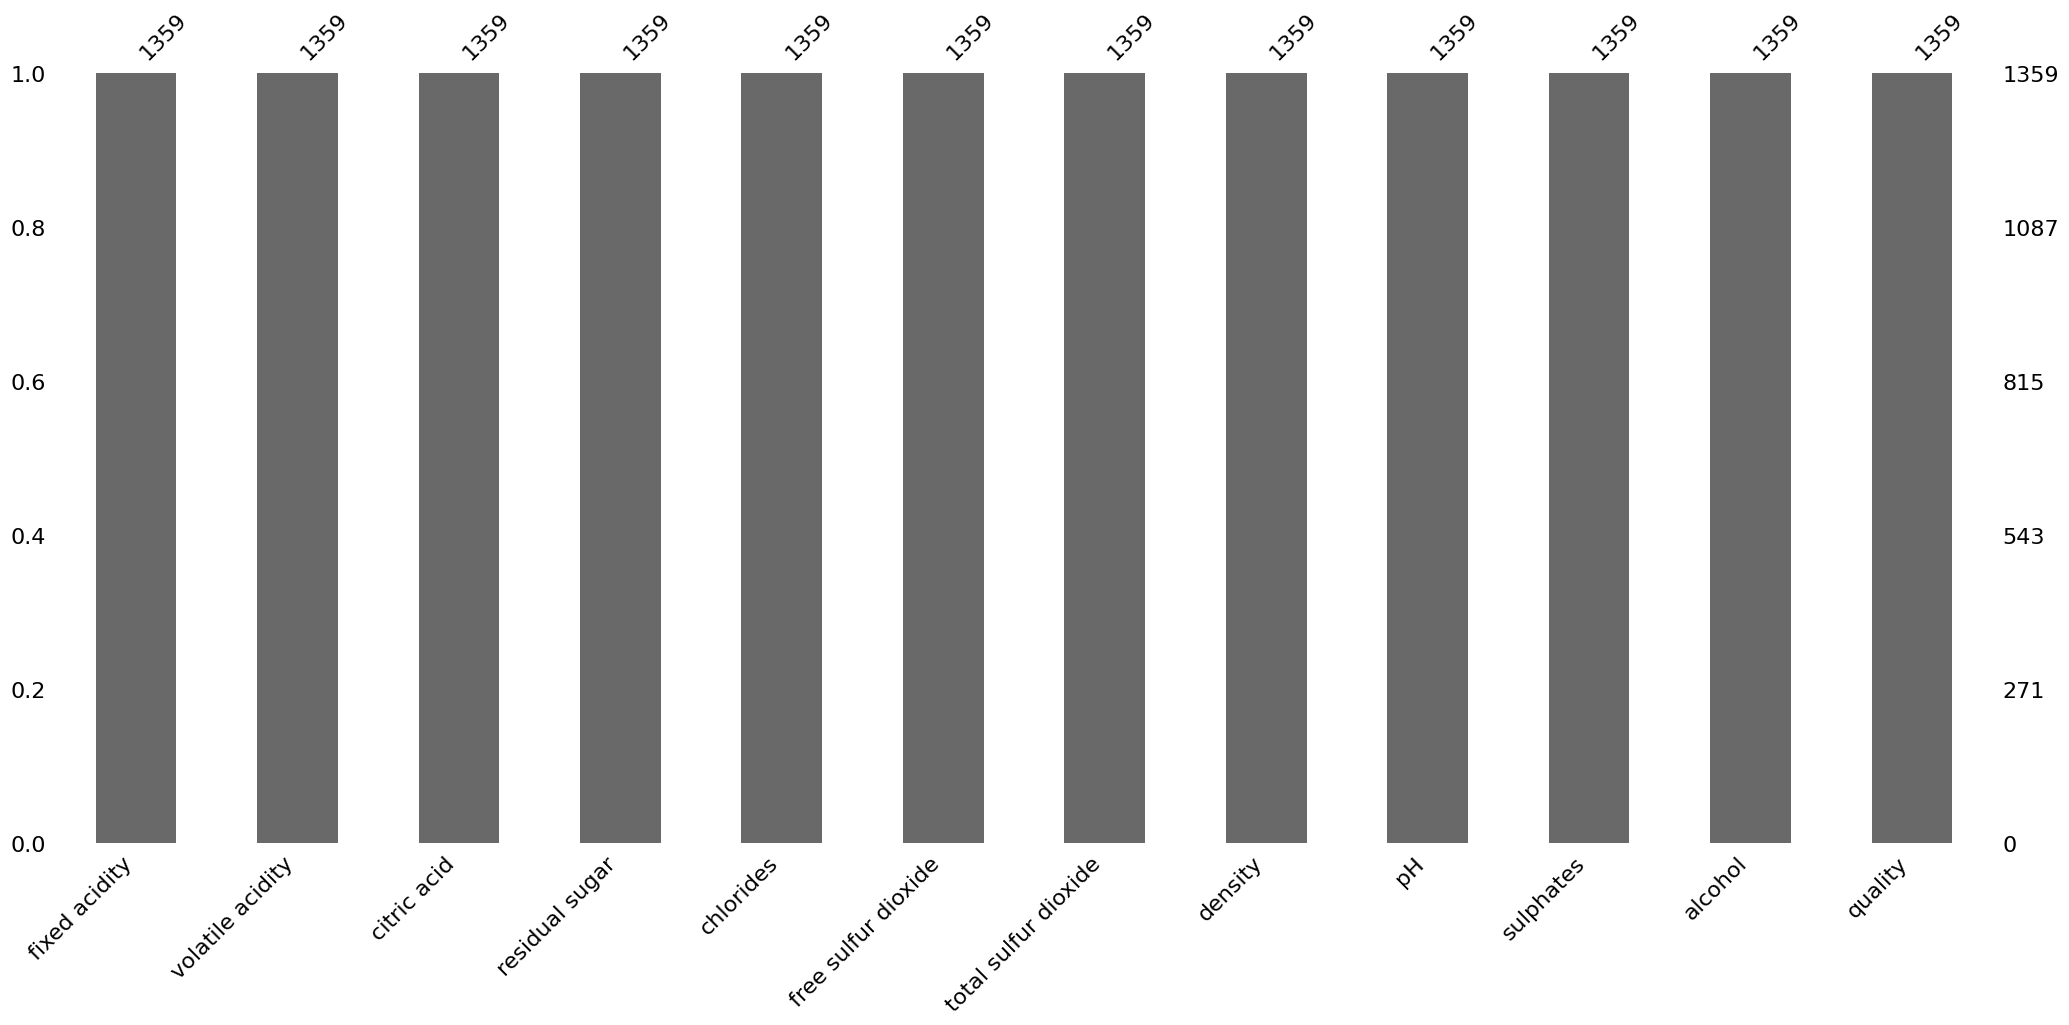

In [202]:
import missingno
missingno.bar(df)

<Axes: >

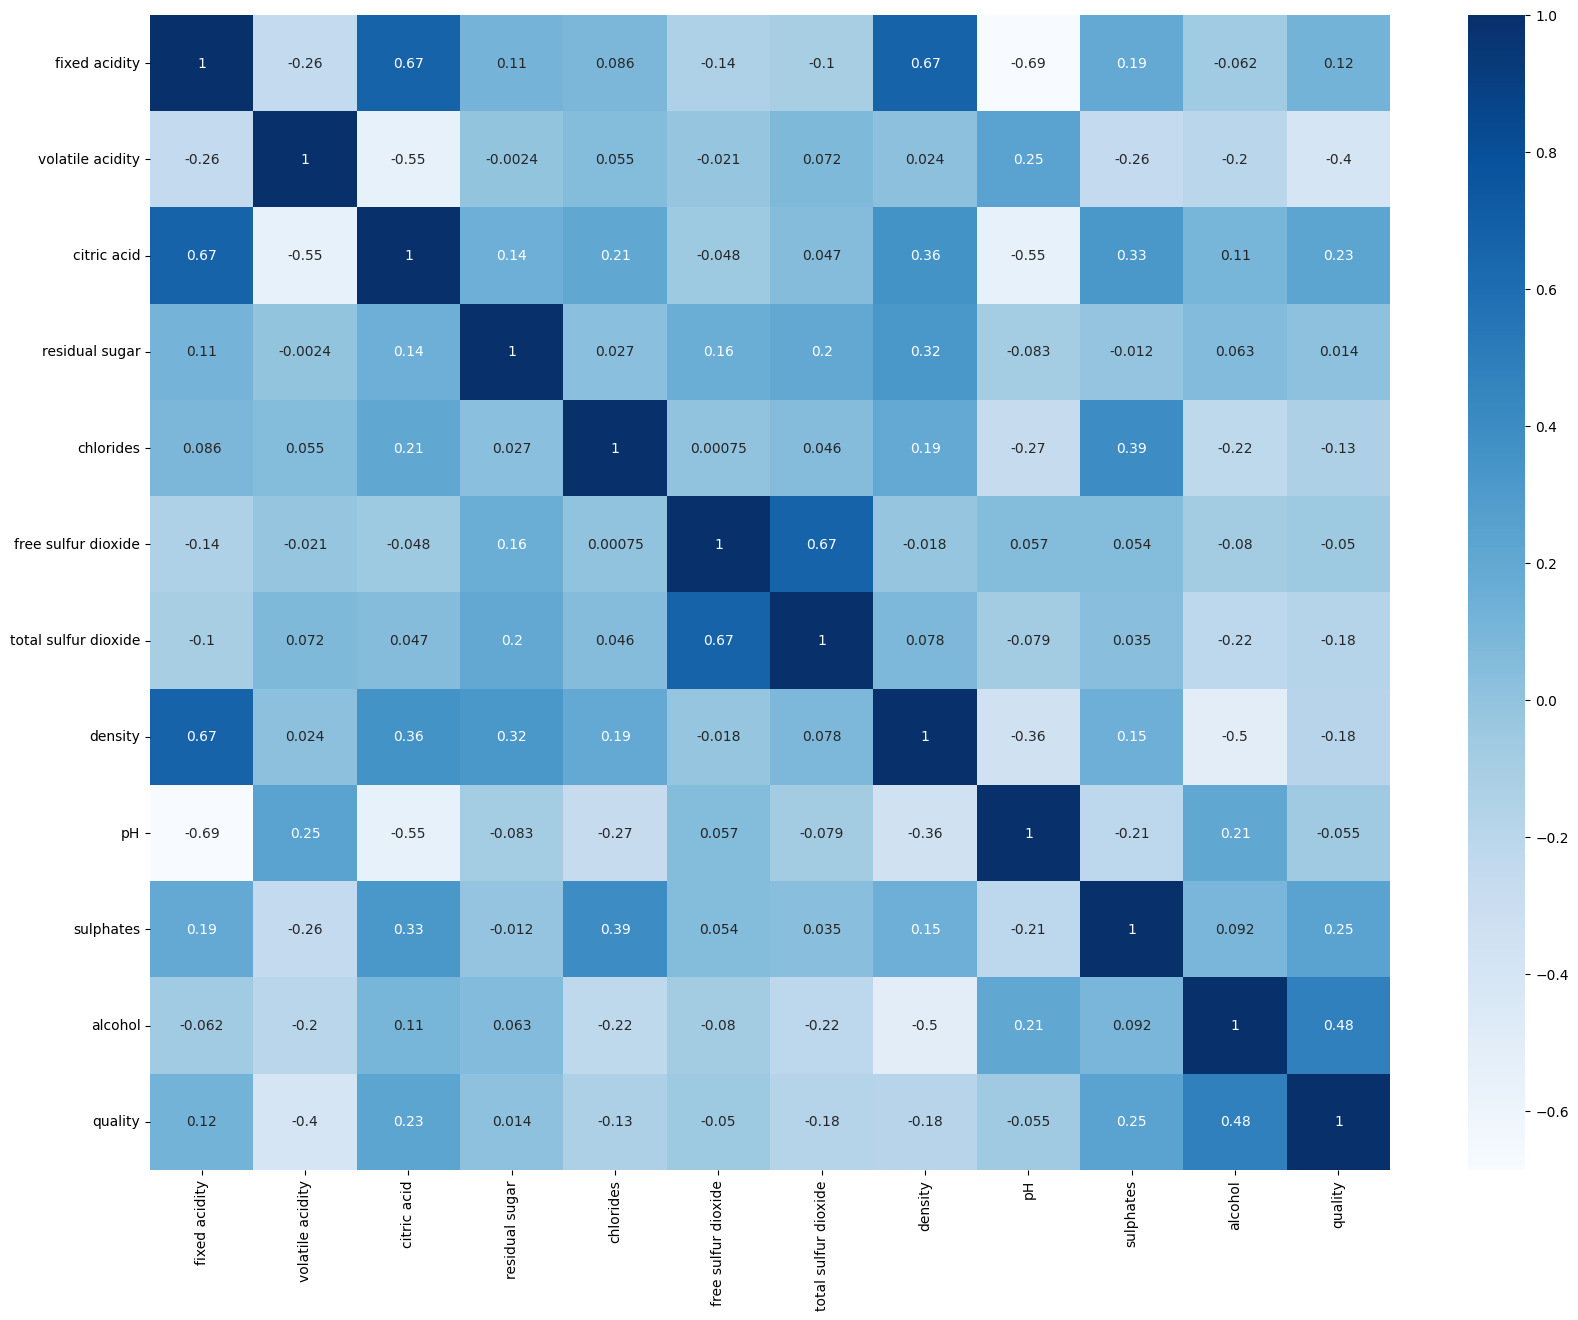

In [203]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(),annot=True,cmap="Blues")

<Axes: >

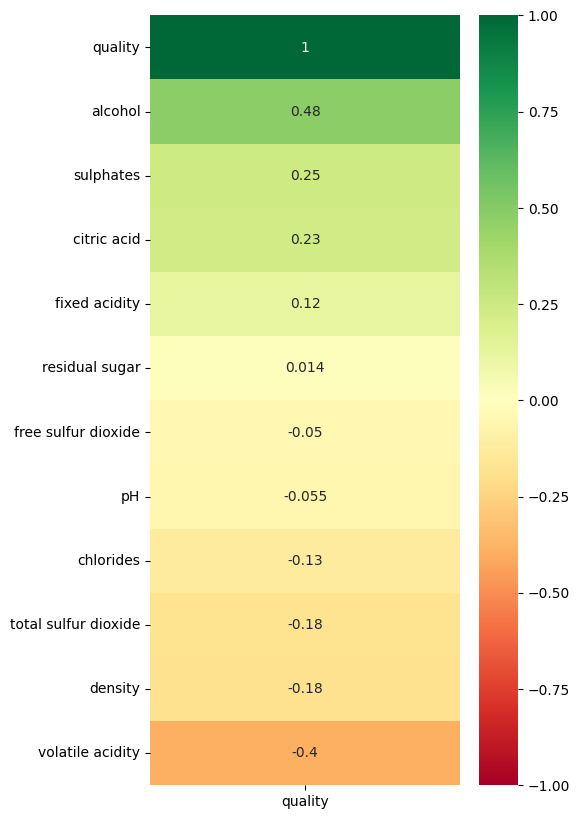

In [204]:
plt.figure(figsize=(5, 10))
sns.heatmap(df.corr()[['quality']].sort_values(by='quality', ascending=False),
            annot=True, cmap='RdYlGn', vmin=-1, vmax=1)

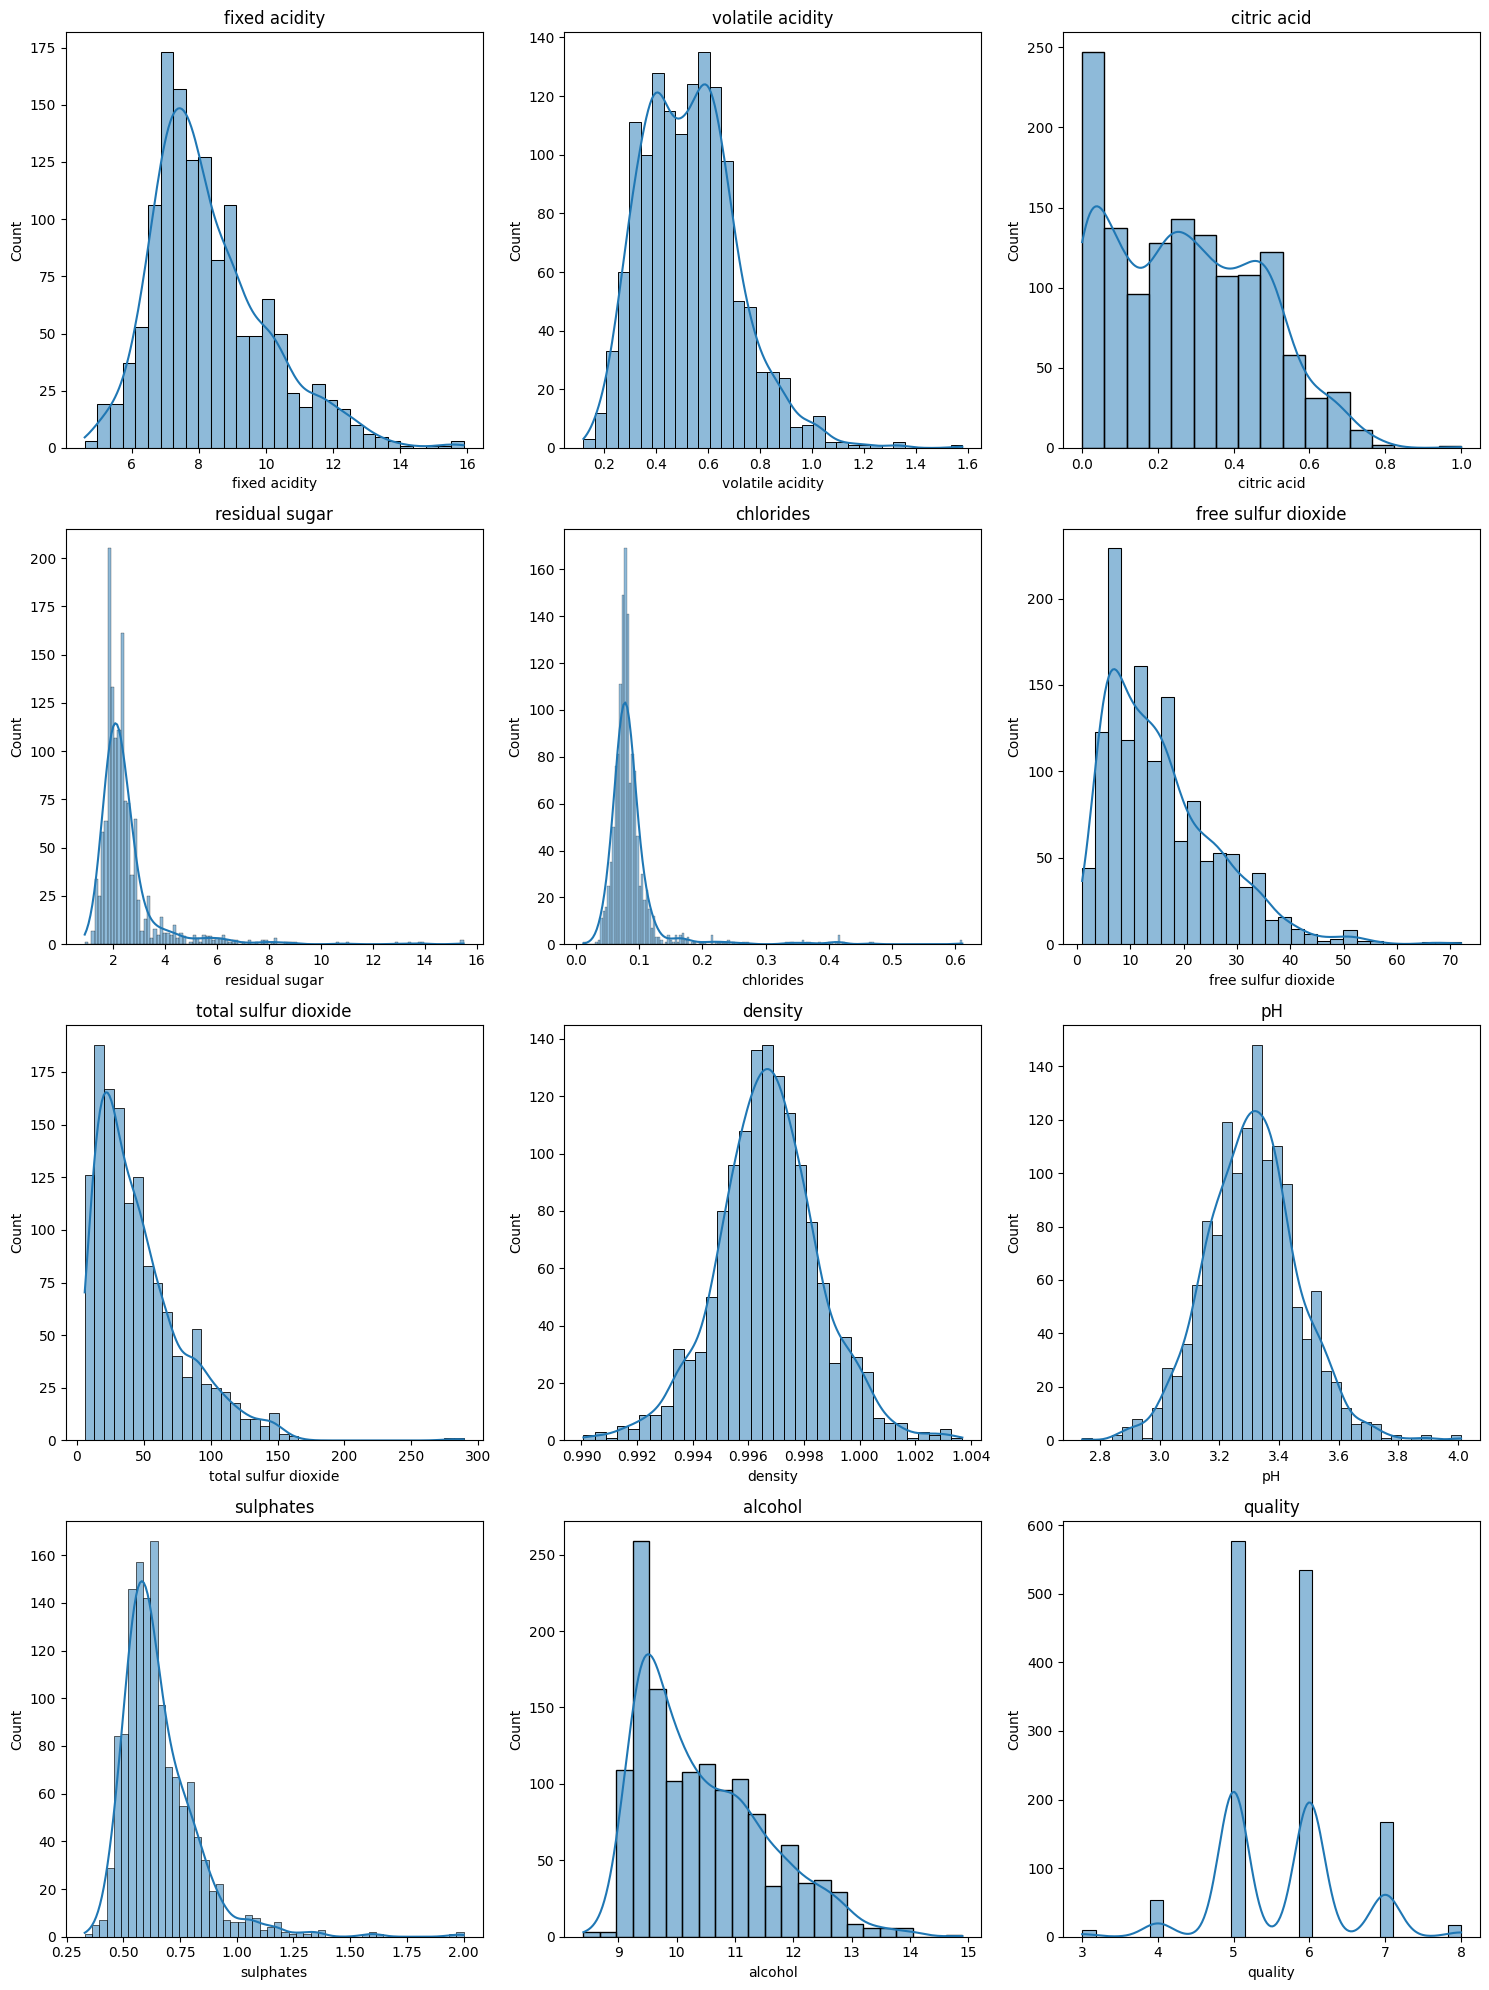

In [205]:
cols = df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()

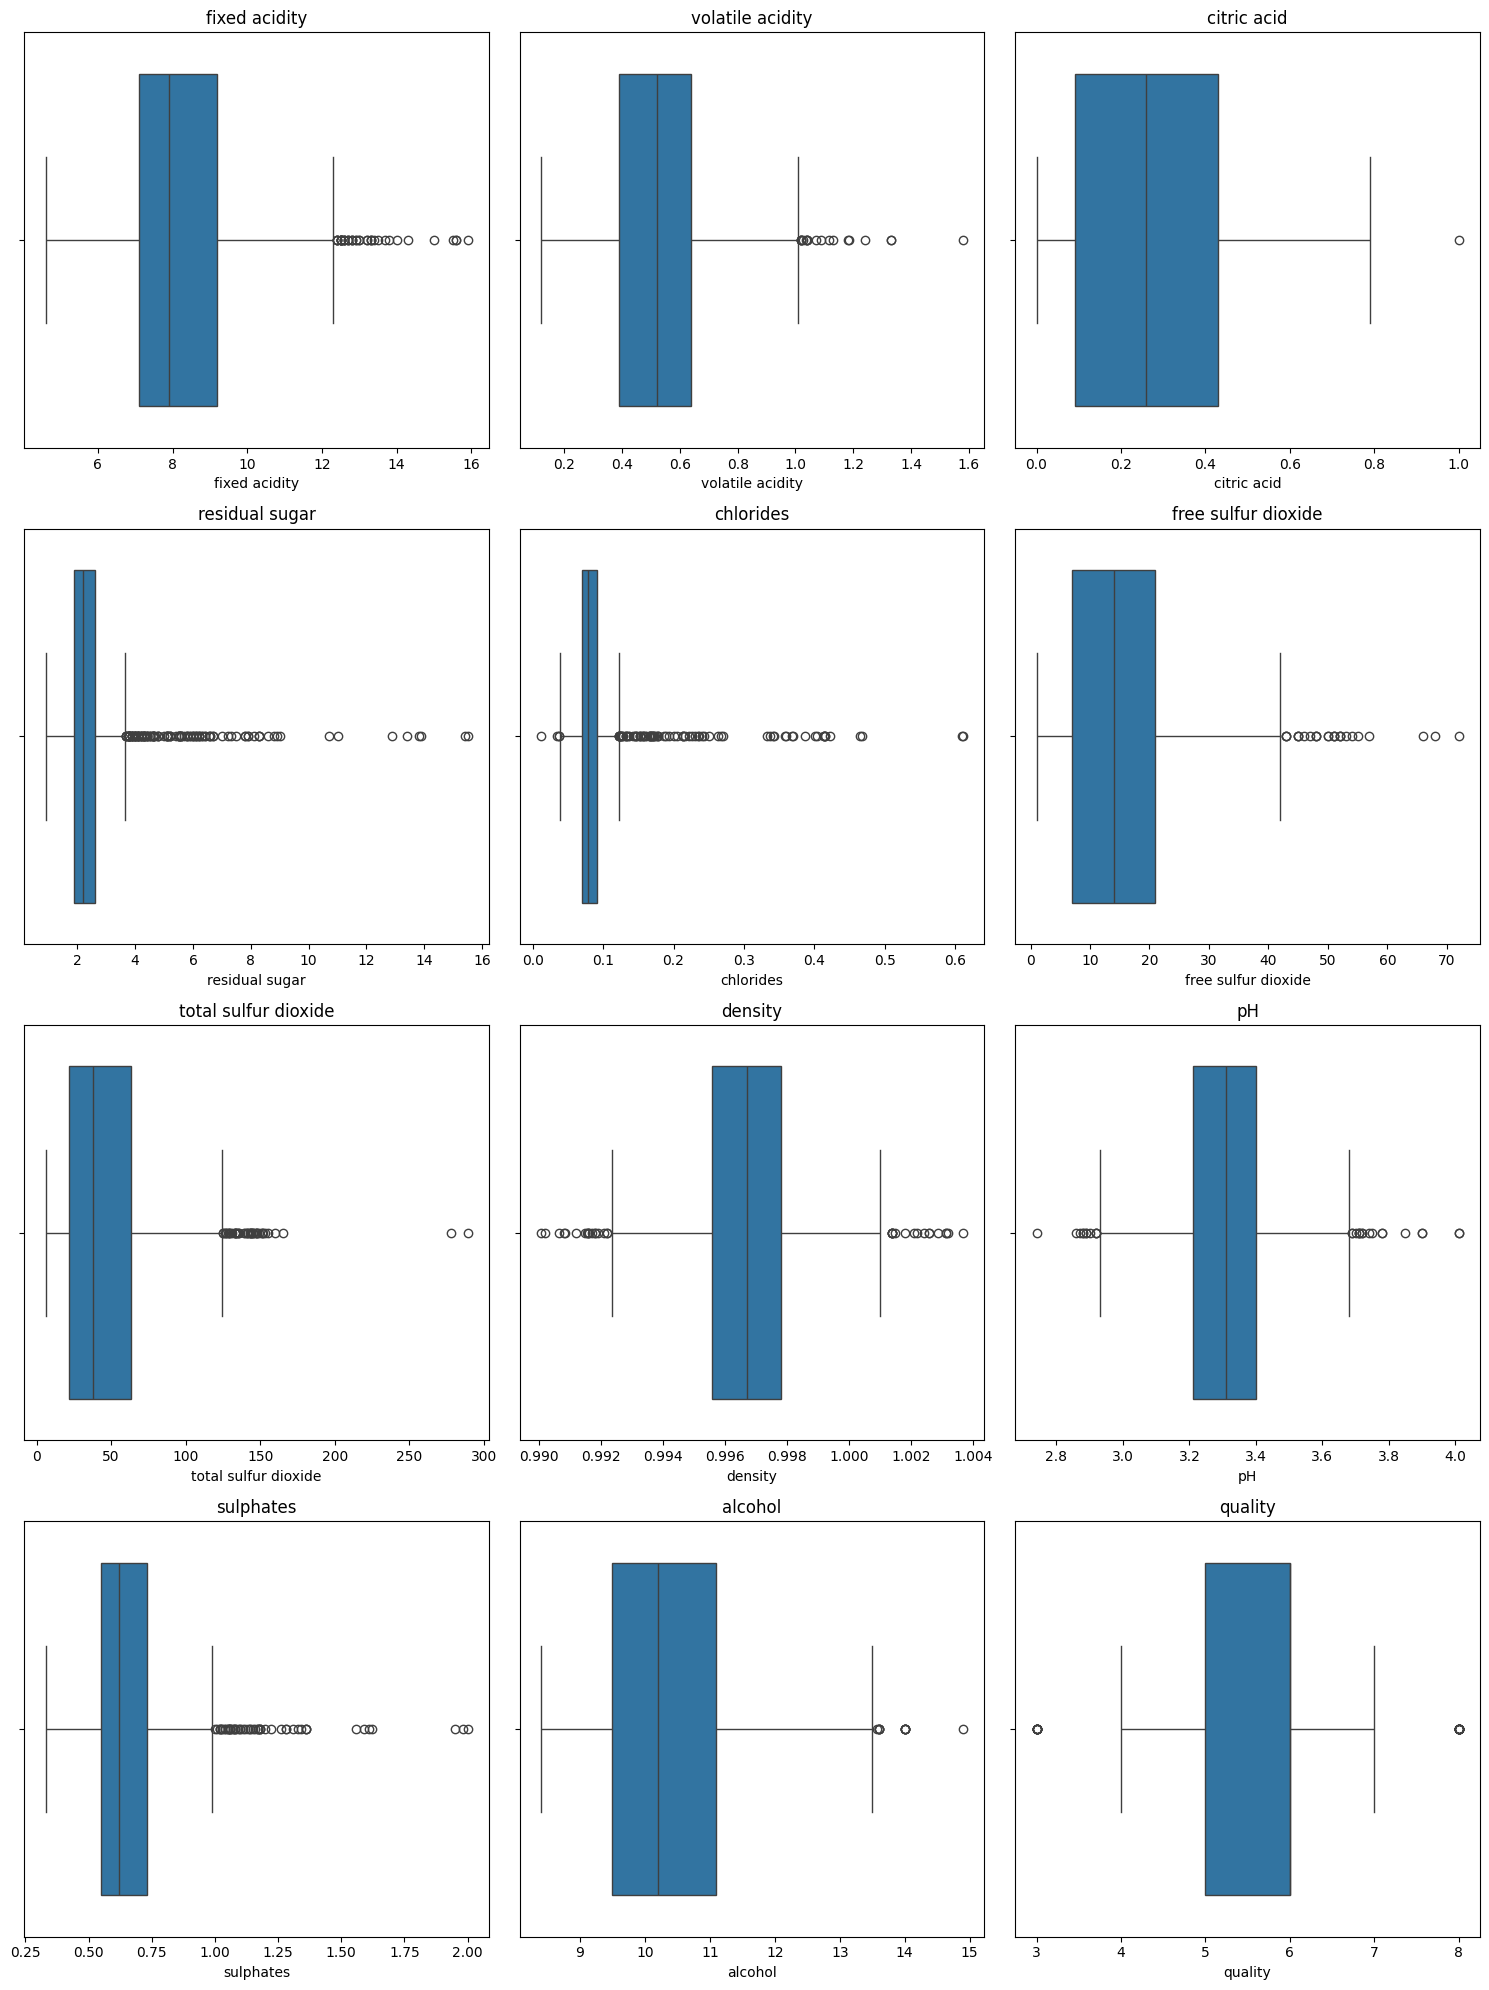

In [206]:
cols = df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

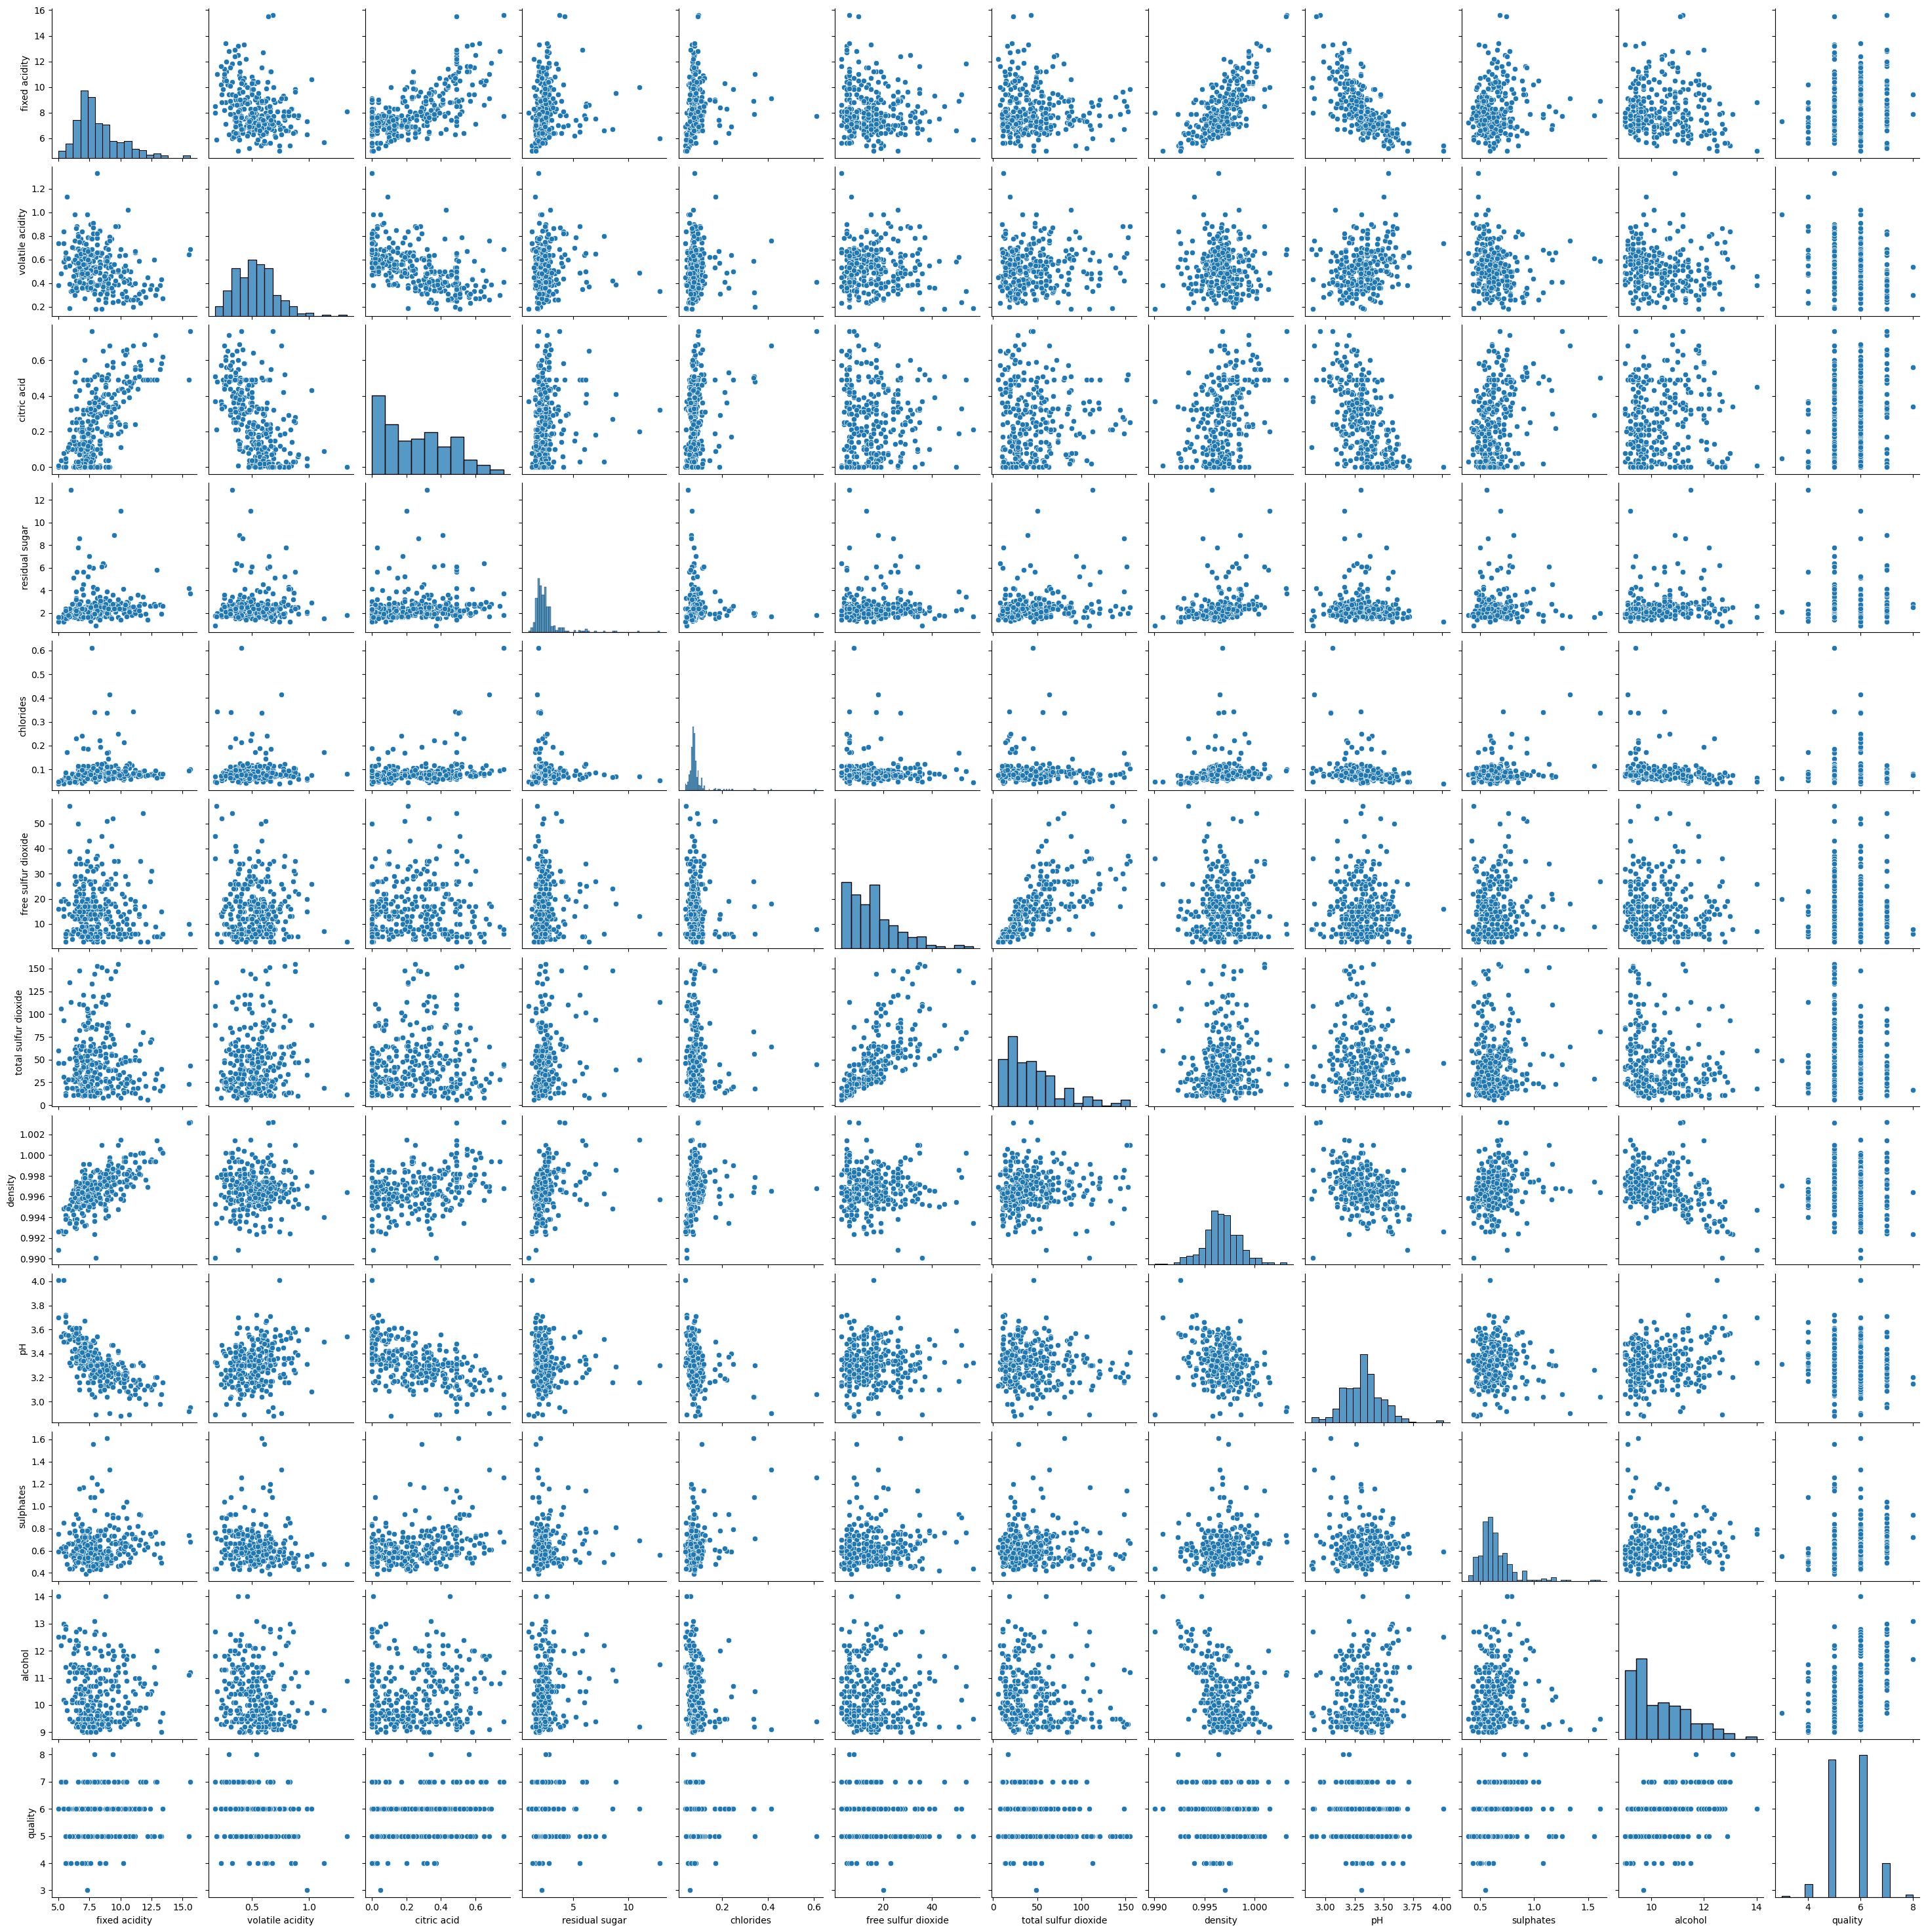

In [207]:
sns.pairplot(df.sample(300))

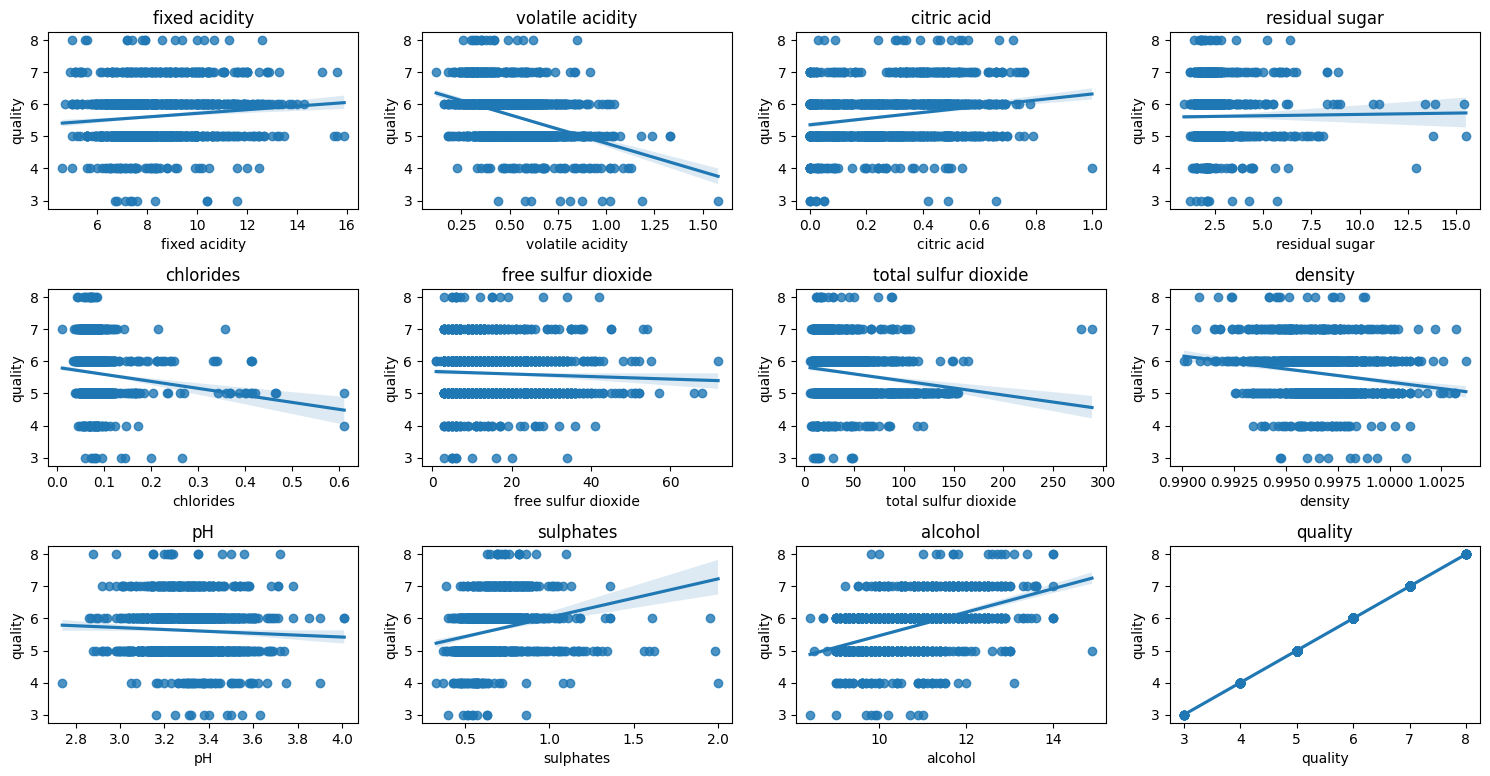

In [208]:
plt.figure(figsize=(15,10))

for i, col in enumerate(df):
    plt.subplot(4, 4, i+1)
    sns.regplot(x=df[col], y=df["quality"])
    plt.title(col)
plt.tight_layout()
plt.show()

# ***Data Preprocessing***





**Handling Outlires**

In [209]:
for col in df.select_dtypes(exclude="int"):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

In [210]:
df["quality_class"] = df["quality"].apply(lambda x: 1 if x >= 7 else 0)

In [211]:
X = df.drop(["quality", "quality_class"], axis=1)
y = df["quality_class"]

In [212]:
y

,quality_class
0,0
1,0
2,0
3,0
5,0
...,...
1593,0
1594,0
1595,0
1597,0


In [213]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [214]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [215]:
models = {
    "KNN": (
        KNeighborsClassifier(),
        {
            "n_neighbors": [3,5,7,9],
            "weights": ["uniform","distance"]
        }
    ),
    "LogisticRegression": (
        LogisticRegression(max_iter=10000),
        {
            "C": [0.1,1,10]
        }
    ),
    "DecisionTree": (
        DecisionTreeClassifier(random_state=42),
        {
            "max_depth": [None,5,10,20],
            "min_samples_split": [2,5,10]
        }
    ),
    "RandomForest": (
        RandomForestClassifier(random_state=42),
        {
            "n_estimators": [100,200],
            "max_depth": [None,10,20]
        }
    ),
    "GradientBoosting": (
        GradientBoostingClassifier(random_state=42),
        {
            "n_estimators": [100,200],
            "learning_rate": [0.01,0.1]
        }
    ),
    "AdaBoost": (
        AdaBoostClassifier(random_state=42),
        {
            "n_estimators": [50,100,200],
            "learning_rate": [0.01,0.1,1]
        }
    ),
    "Bagging": (
        BaggingClassifier(random_state=42),
        {
            "n_estimators": [10,50,100]
        }
    ),
    "ExtraTrees": (
        ExtraTreesClassifier(random_state=42),
        {
            "n_estimators": [100,200],
            "max_depth": [None,10,20]
        }
    ),
    "SVC": (
        SVC(probability=True),
        {
            "C": [0.1,1,10],
            "kernel": ["rbf","linear"]
        }
    ),
    "XGB": (
        XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42),
        {
            "n_estimators": [100,200],
            "learning_rate": [0.01,0.1],
            "max_depth": [3,5,7]
        }
    ),
    "LGBM": (
        LGBMClassifier(random_state=42, verbose=-1),
        {
            "n_estimators": [100,200],
            "learning_rate": [0.01,0.1]
        }
    ),
    "CatBoost": (
        CatBoostClassifier(random_state=42, verbose=0),
        {
            "iterations": [100,200],
            "learning_rate": [0.01,0.1],
            "depth": [4,6,8]
        }
    )
}


In [216]:
results = []

for name, (model, params) in models.items():
    grid = GridSearchCV(model, params, cv=5, scoring="f1", n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:,1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,GradientBoosting,0.911765,0.666667,0.588235,0.625000,0.894587
1,SVC,0.900735,0.612903,0.558824,0.584615,0.848492
2,RandomForest,0.915441,0.761905,0.470588,0.581818,0.892857
3,Bagging,0.915441,0.761905,0.470588,0.581818,0.871540
4,DecisionTree,0.889706,0.558824,0.558824,0.558824,0.794303
5,CatBoost,0.908088,0.714286,0.441176,0.545455,0.895082
6,KNN,0.886029,0.545455,0.529412,0.537313,0.771997
7,LogisticRegression,0.897059,0.615385,0.470588,0.533333,0.883712
8,XGB,0.897059,0.615385,0.470588,0.533333,0.874073
9,AdaBoost,0.878676,0.517241,0.441176,0.476190,0.886060


In [220]:
grid.best_estimator_

CatBoostClassifier(depth=6, iterations=200, learning_rate=0.1, random_state=42, verbose=0)

In [225]:
best_model = grid.best_estimator_
importances = best_model.get_feature_importance()

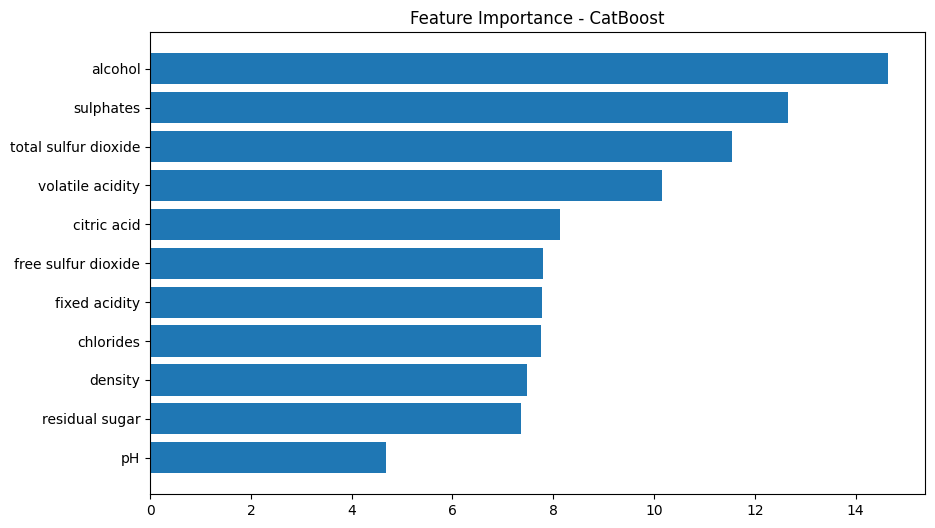

,Feature,Importance
10,alcohol,14.645436
9,sulphates,12.659543
6,total sulfur dioxide,11.554252
1,volatile acidity,10.151605
2,citric acid,8.138883
5,free sulfur dioxide,7.796092
0,fixed acidity,7.783769
4,chlorides,7.747905
7,density,7.486398
3,residual sugar,7.349990


In [226]:
fi_df = pd.DataFrame({"Feature": features, "Importance": importances}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(fi_df["Feature"], fi_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - CatBoost")
plt.show()

fi_df